# 🧠 Exercício: Visualização de Letras de Músicas com Redução de Dimensionalidade

Neste exercício, você irá trabalhar com um subconjunto de letras de músicas para explorar diferentes técnicas de redução de dimensionalidade: **PCA**, **t-SNE** e **Random Projection**. O objetivo é gerar representações 2D dessas letras e visualizar como cada técnica projeta os dados.

---

## ✅ Passo 1: Carregue os dados

Carregue o arquivo `musicas_subsampled.csv`, que deve conter as colunas:

- `nome_musica`
- `artista`
- `ano`
- `letra`

---

## ✅ Passo 2: Transforme as letras em vetores binários

Utilize `TfidfVectorizer` com `binary=True` para criar uma matriz de presença/ausência de palavras nas letras.

    from sklearn.feature_extraction.text import TfidfVectorizer
    import pandas as pd

    vectorizer = TfidfVectorizer(lowercase=True, binary=True)
    X = vectorizer.fit_transform(df['letra'].fillna(''))
    X_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

---

## ✅ Passo 3: Separe os metadados das features

Crie um novo `DataFrame` com os dados originais e as features numéricas geradas.

    df_bin = pd.concat([df[['nome_musica', 'artista', 'ano']].reset_index(drop=True), X_df], axis=1)
    features = df_bin.drop(columns=['nome_musica', 'artista', 'ano'])

---

## ✅ Passo 4: Aplique PCA

Utilize `PCA` do `sklearn.decomposition` para reduzir a dimensionalidade das features para 2 componentes principais.

    from sklearn.decomposition import PCA

    pca = PCA(n_components=2, random_state=42)
    df_bin['pca_1'], df_bin['pca_2'] = pca.fit_transform(features).T

---

## ✅ Passo 5: Aplique t-SNE

Utilize `TSNE` do `sklearn.manifold` com 2 dimensões para obter uma projeção alternativa.

    from sklearn.manifold import TSNE

    tsne = TSNE(n_components=2, random_state=42)
    df_bin['tsne_1'], df_bin['tsne_2'] = tsne.fit_transform(features).T

---


## ✅ Passo 7: Visualize os resultados

Crie três gráficos lado a lado para comparar as projeções obtidas por PCA, t-SNE e Random Projection.

---

## 🎯 Objetivo

Compare visualmente os resultados. Você acha algum padrão? Vamos entender o que esse padrão representa no próximo exercício!


In [1]:
# By Vitor Mello
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.random_projection import GaussianRandomProjection

# 1. Carregar dados
df = pd.read_csv("musicas_subsampled.csv")

# 2. Vetorize
vectorizer = TfidfVectorizer(lowercase=True, binary=True)
X = vectorizer.fit_transform(df['letra'].fillna(''))
X_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# 3. Remove Metadados
df_bin = pd.concat([
    df[['nome_musica', 'artista', 'ano']].reset_index(drop=True),
    X_df
], axis=1)

features = df_bin.drop(columns=['nome_musica', 'artista', 'ano'])

# 4. Apply Random Projection
rp = GaussianRandomProjection(n_components=2, random_state=42)
df_bin['rp1'], df_bin['rp2'] = rp.fit_transform(features).T

# 5. Apply PCA
pca = PCA(n_components=2, random_state=42)
df_bin['pca1'], df_bin['pca2'] = pca.fit_transform(features).T

# 6. Apply TSNE
tsne = TSNE(n_components=2, random_state=42)
df_bin['tsne_1'], df_bin['tsne_2'] = tsne.fit_transform(features).T

Text(0.5, 1.0, 'TSNE')

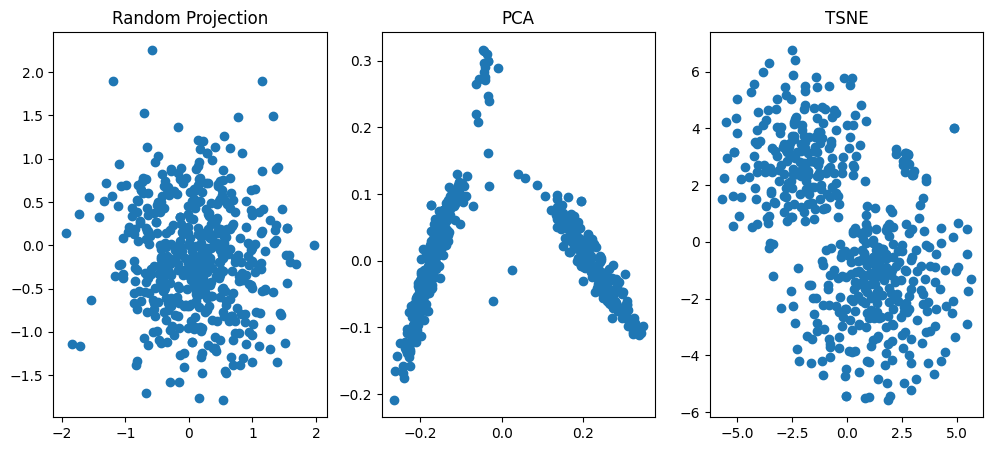

In [2]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(12, 5))

axs[0].scatter(df_bin['rp1'], df_bin['rp2'])
axs[0].set_title("Random Projection")
axs[1].scatter(df_bin['pca1'], df_bin['pca2'])
axs[1].set_title("PCA")
axs[2].scatter(df_bin['tsne_1'], df_bin['tsne_2'])
axs[2].set_title("TSNE")

## 🧪 Exercício: Agrupamento com KMeans sobre Representações PCA e t-SNE

Após reduzir a dimensionalidade dos dados com **PCA** e **t-SNE**, seu objetivo agora é:

- Aplicar o algoritmo de agrupamento **KMeans** sobre essas representações;
- Adicionar os rótulos de cluster ao seu dataset;
- Visualizar os agrupamentos;
- Analisar se os agrupamentos capturam algum padrão interessante (como estilo musical, época, artista etc.).

---

### ✅ Passo 1: Aplique KMeans nos componentes de PCA

Use o `KMeans` com `n_clusters=2` nos dois componentes principais obtidos via PCA.

Adicione os rótulos ao `DataFrame` na coluna:

- `cluster_pca`

    from sklearn.cluster import KMeans

    kmeans_pca = KMeans(n_clusters=2, random_state=42)
    df_bin['cluster_pca'] = kmeans_pca.fit_predict(pca_result)

---

### ✅ Passo 2: Aplique KMeans nos componentes de t-SNE

Repita o processo, agora usando os dois componentes gerados com t-SNE.

Adicione a coluna:

- `cluster_tsne`

    kmeans_tsne = KMeans(n_clusters=2, random_state=42)
    df_bin['cluster_tsne'] = kmeans_tsne.fit_predict(tsne_result)

---

### ✅ Passo 3: Visualize os agrupamentos

Crie dois gráficos, um com os componentes do PCA e outro com os do t-SNE, colorindo os pontos de acordo com os rótulos de cluster atribuídos.

---

### ✅ Passo 4: Explore o dataset com as colunas de cluster

Agora que `df_bin` contém as colunas `cluster_pca` e `cluster_tsne`, analise se esses agrupamentos revelam padrões interessantes. Descreva o que você encontrou.

---


<Axes: xlabel='tsne_1', ylabel='tsne_2'>

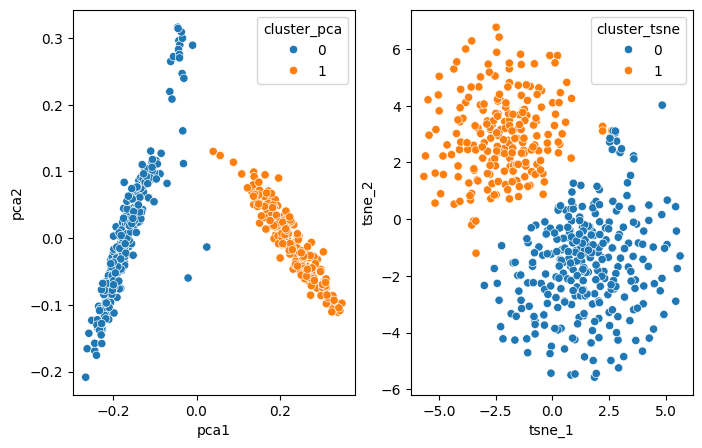

In [3]:
from sklearn.cluster import KMeans
import seaborn as sns

# KMeans calculation
kmeans_pca = KMeans(n_clusters=2, random_state=42)
df_bin['cluster_pca'] = kmeans_pca.fit_predict(df_bin[['pca1', 'pca2']])

kmeans_tsne = KMeans(n_clusters=2, random_state=42)
df_bin['cluster_tsne'] = kmeans_pca.fit_predict(df_bin[['tsne_1', 'tsne_2']])

fig, axs = plt.subplots(1, 2, figsize=(8, 5))

sns.scatterplot(data=df_bin, x='pca1', y='pca2', hue='cluster_pca', ax=axs[0])
sns.scatterplot(data=df_bin, x='tsne_1', y='tsne_2', hue='cluster_tsne', ax=axs[1])

## 🧪 Exercício: Padrões dentro do padrão (não é obrigatório para a graduação)

Após aplicar t-sne e pca e clusterizar os dados anteriores, vocês devem aplicar t-sne e pca dentro de cada cluster individual e procurar por padrões.


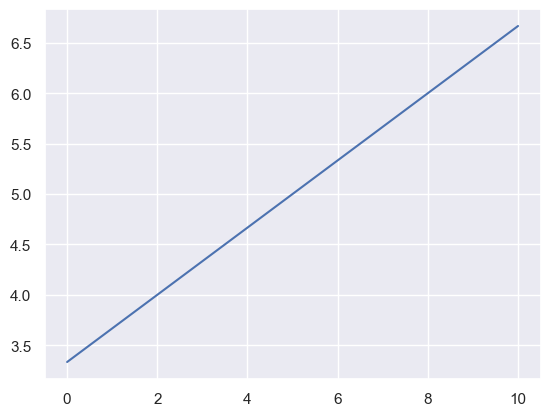

In [12]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_theme()

p1 = 7.5
p2 = 2.5

notas = np.arange(0, 101)/10
plt.plot(notas, [(p1+p2+i)/3 for i in notas])


/var/folders/9j/vn430hgj54s92fj0p3wfvhxh0000gn/T/ipykernel_65539/1895543236.py:1: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.linspace(0,1, 20), np.log(np.linspace(0,1, 20)))


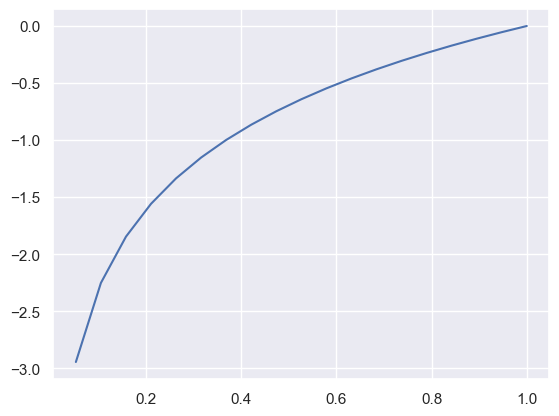

In [18]:
plt.plot(np.linspace(0,1, 20), np.log(np.linspace(0,1, 20)))

/var/folders/9j/vn430hgj54s92fj0p3wfvhxh0000gn/T/ipykernel_65539/3195356469.py:1: RuntimeWarning: divide by zero encountered in scalar divide
  plt.plot(np.linspace(0,1, 20), [1/i for i in np.linspace(0,1, 20)])


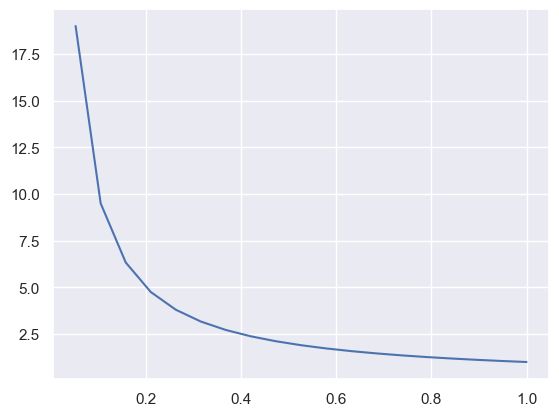

In [19]:
plt.plot(np.linspace(0,1, 20), [1/i for i in np.linspace(0,1, 20)])

In [26]:
from scipy import stats

X = stats.Normal(mu=0, sigma=1)
Y = -X

# plt.plot(np.linspace(-4,4, 50), [X.cdf(i) for i in np.linspace(-4,4, 50)])
# plt.plot(np.linspace(-4,4, 50), [Y.cdf(i) for i in np.linspace(-4,4, 50)])

print(1-X.cdf(1), X.cdf(-1))

0.15865525393145707 0.15865525393145707
